In [25]:
import os
import sqlite3
import ast
import json
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


## CONNECT TO THE SQLITE3 DATABASE

In [3]:
con = sqlite3.connect("cademycode.db")
cur = con.cursor()

#reading all theb table
table_list = [a for a in cur.execute("SELECT name FROM sqlite_master WHERE type = 'table'")]
print(table_list)

[('cademycode_students',), ('cademycode_courses',), ('cademycode_student_jobs',)]


## EXTRACT THE TABLES FROM THE DB FILES



In [4]:
student_raw = pd.read_sql_query("SELECT * FROM cademycode_students",con)
courses_raw = pd.read_sql_query("SELECT * FROM cademycode_courses",con)
jobs_raw = pd.read_sql_query("SELECT * FROM cademycode_student_jobs",con)


In [5]:
print("student_raw:", len(student_raw))
print("courses_raw:", len(courses_raw))
print("jobs_raw:", len(jobs_raw))

student_raw: 5000
courses_raw: 10
jobs_raw: 13


## WORKING WITH THE STUDENTS TABLE

In [6]:
student_raw.head(10)

,uuid,name,dob,sex,contact_info,job_id,num_course_taken,current_career_path_id,time_spent_hrs
0,1,Annabelle Avery,1943-07-03,F,"{""mailing_address"": ""303 N Timber Key, Irondal...",7.0,6.0,1.0,4.99
1,2,Micah Rubio,1991-02-07,M,"{""mailing_address"": ""767 Crescent Fair, Shoals...",7.0,5.0,8.0,4.4
2,3,Hosea Dale,1989-12-07,M,"{""mailing_address"": ""P.O. Box 41269, St. Bonav...",7.0,8.0,8.0,6.74
3,4,Mariann Kirk,1988-07-31,F,"{""mailing_address"": ""517 SE Wintergreen Isle, ...",6.0,7.0,9.0,12.31
4,5,Lucio Alexander,1963-08-31,M,"{""mailing_address"": ""18 Cinder Cliff, Doyles b...",7.0,14.0,3.0,5.64
5,6,Shavonda Mcmahon,1989-10-15,F,"{""mailing_address"": ""P.O. Box 81591, Tarpon Sp...",6.0,10.0,3.0,10.12
6,7,Terrell Bleijenberg,1959-05-05,M,"{""mailing_address"": ""P.O. Box 53471, Oskaloosa...",2.0,9.0,8.0,24.17
7,8,Stanford Allan,1997-11-22,M,"{""mailing_address"": ""255 Spring Avenue, Point ...",3.0,3.0,1.0,19.54
8,9,Tricia Delacruz,1961-10-20,F,"{""mailing_address"": ""997 Dewy Apple, Lake Lind...",1.0,6.0,9.0,1.75
9,10,Regenia van der Helm,1999-02-23,N,"{""mailing_address"": ""220 Middle Ridge, Falcon ...",5.0,7.0,6.0,13.55


In [7]:
student_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   uuid                    5000 non-null   int64 
 1   name                    5000 non-null   object
 2   dob                     5000 non-null   object
 3   sex                     5000 non-null   object
 4   contact_info            5000 non-null   object
 5   job_id                  4995 non-null   object
 6   num_course_taken        4749 non-null   object
 7   current_career_path_id  4529 non-null   object
 8   time_spent_hrs          4529 non-null   object
dtypes: int64(1), object(8)
memory usage: 351.7+ KB



### A couple things I notice when examining the DataFrame so far:

#### 1:contact_info appears to be a dictionary, which will require additional work to explode it into seperate columns
#### 2:each row has a UUID, which means one student can only be one row
#### 3:dob seems to be date of birth, will want to make sure it is a datetime object
#### 3.1:calculating age from DoB might be useful as a grouping column
#### 4:none of the numerical columns are coming in as floats or integers
##### 4.1 job_id and current_career_path_id should be treated as categorical data since they are IDs
#### 5:looks like there is missing data in job_id, current_career_path_id, and current_career_path_id

## CALCULATING APPROXIMATE AGE

In [8]:
now = pd.Timestamp.now()
student_raw['dob'] = pd.to_datetime(student_raw['dob'])
student_raw['age'] = (now - student_raw['dob']).dt.days // 365.25

student_raw['age_group'] = (student_raw['age'] // 10) * 10

In [9]:
student_raw.head()


,uuid,name,dob,sex,contact_info,job_id,num_course_taken,current_career_path_id,time_spent_hrs,age,age_group
0,1,Annabelle Avery,1943-07-03,F,"{""mailing_address"": ""303 N Timber Key, Irondal...",7.0,6.0,1.0,4.99,83.0,80.0
1,2,Micah Rubio,1991-02-07,M,"{""mailing_address"": ""767 Crescent Fair, Shoals...",7.0,5.0,8.0,4.4,35.0,30.0
2,3,Hosea Dale,1989-12-07,M,"{""mailing_address"": ""P.O. Box 41269, St. Bonav...",7.0,8.0,8.0,6.74,36.0,30.0
3,4,Mariann Kirk,1988-07-31,F,"{""mailing_address"": ""517 SE Wintergreen Isle, ...",6.0,7.0,9.0,12.31,38.0,30.0
4,5,Lucio Alexander,1963-08-31,M,"{""mailing_address"": ""18 Cinder Cliff, Doyles b...",7.0,14.0,3.0,5.64,62.0,60.0


## EXPLODE THE DICTIONARY

In [10]:

def safe_parse(x):
  if pd.isna(x):
    return {}
  if isinstance(x, dict):
    return x
  if isinstance(x, str):
    try:
      return json.loads(x)
    except (json.JSONDecodeError, TypeError):
      try:
        return ast.literal_eval(x)
      except Exception:
        return {}
  return {}



student_raw['contact_info'] = student_raw["contact_info"].apply(safe_parse)
student_contact = pd.json_normalize(student_raw['contact_info'])


student_contact.index = student_raw.index


student_raw = student_raw.drop(columns=['contact_info']).join(student_contact)

In [11]:
student_raw.head(10)

,uuid,name,dob,sex,job_id,num_course_taken,current_career_path_id,time_spent_hrs,age,age_group,mailing_address,email
0,1,Annabelle Avery,1943-07-03,F,7.0,6.0,1.0,4.99,83.0,80.0,"303 N Timber Key, Irondale, Wisconsin, 84736",annabelle_avery9376@woohoo.com
1,2,Micah Rubio,1991-02-07,M,7.0,5.0,8.0,4.4,35.0,30.0,"767 Crescent Fair, Shoals, Indiana, 37439",rubio6772@hmail.com
2,3,Hosea Dale,1989-12-07,M,7.0,8.0,8.0,6.74,36.0,30.0,"P.O. Box 41269, St. Bonaventure, Virginia, 83637",hosea_dale8084@coldmail.com
3,4,Mariann Kirk,1988-07-31,F,6.0,7.0,9.0,12.31,38.0,30.0,"517 SE Wintergreen Isle, Lane, Arkansas, 82242",kirk4005@hmail.com
4,5,Lucio Alexander,1963-08-31,M,7.0,14.0,3.0,5.64,62.0,60.0,"18 Cinder Cliff, Doyles borough, Rhode Island,...",alexander9810@hmail.com
5,6,Shavonda Mcmahon,1989-10-15,F,6.0,10.0,3.0,10.12,36.0,30.0,"P.O. Box 81591, Tarpon Springs, Montana, 37057",shavonda5863@coldmail.com
6,7,Terrell Bleijenberg,1959-05-05,M,2.0,9.0,8.0,24.17,67.0,60.0,"P.O. Box 53471, Oskaloosa, Virginia, 85274",bleijenberg188@hmail.com
7,8,Stanford Allan,1997-11-22,M,3.0,3.0,1.0,19.54,28.0,20.0,"255 Spring Avenue, Point Baker, Texas, 15796",stanford_allan8055@coldmail.com
8,9,Tricia Delacruz,1961-10-20,F,1.0,6.0,9.0,1.75,64.0,60.0,"997 Dewy Apple, Lake Lindsey, Washington, 78266",tricia_delacruz6622@woohoo.com
9,10,Regenia van der Helm,1999-02-23,N,5.0,7.0,6.0,13.55,27.0,20.0,"220 Middle Ridge, Falcon Heights, New Mexico, ...",regenia6908@inlook.com


In [12]:
split_address = student_raw['mailing_address'].str.split(r',\s*', expand=True, n=3 )
split_address.columns = ["street","city","state","zip_code"]
student_raw = student_raw.drop(columns=['mailing_address']).join(split_address)

In [13]:
print(student_raw.columns.tolist())

['uuid', 'name', 'dob', 'sex', 'job_id', 'num_course_taken', 'current_career_path_id', 'time_spent_hrs', 'age', 'age_group', 'email', 'street', 'city', 'state', 'zip_code']


In [14]:
student_raw.head(10)

,uuid,name,dob,sex,job_id,num_course_taken,current_career_path_id,time_spent_hrs,age,age_group,email,street,city,state,zip_code
0,1,Annabelle Avery,1943-07-03,F,7.0,6.0,1.0,4.99,83.0,80.0,annabelle_avery9376@woohoo.com,303 N Timber Key,Irondale,Wisconsin,84736
1,2,Micah Rubio,1991-02-07,M,7.0,5.0,8.0,4.4,35.0,30.0,rubio6772@hmail.com,767 Crescent Fair,Shoals,Indiana,37439
2,3,Hosea Dale,1989-12-07,M,7.0,8.0,8.0,6.74,36.0,30.0,hosea_dale8084@coldmail.com,P.O. Box 41269,St. Bonaventure,Virginia,83637
3,4,Mariann Kirk,1988-07-31,F,6.0,7.0,9.0,12.31,38.0,30.0,kirk4005@hmail.com,517 SE Wintergreen Isle,Lane,Arkansas,82242
4,5,Lucio Alexander,1963-08-31,M,7.0,14.0,3.0,5.64,62.0,60.0,alexander9810@hmail.com,18 Cinder Cliff,Doyles borough,Rhode Island,73737
5,6,Shavonda Mcmahon,1989-10-15,F,6.0,10.0,3.0,10.12,36.0,30.0,shavonda5863@coldmail.com,P.O. Box 81591,Tarpon Springs,Montana,37057
6,7,Terrell Bleijenberg,1959-05-05,M,2.0,9.0,8.0,24.17,67.0,60.0,bleijenberg188@hmail.com,P.O. Box 53471,Oskaloosa,Virginia,85274
7,8,Stanford Allan,1997-11-22,M,3.0,3.0,1.0,19.54,28.0,20.0,stanford_allan8055@coldmail.com,255 Spring Avenue,Point Baker,Texas,15796
8,9,Tricia Delacruz,1961-10-20,F,1.0,6.0,9.0,1.75,64.0,60.0,tricia_delacruz6622@woohoo.com,997 Dewy Apple,Lake Lindsey,Washington,78266
9,10,Regenia van der Helm,1999-02-23,N,5.0,7.0,6.0,13.55,27.0,20.0,regenia6908@inlook.com,220 Middle Ridge,Falcon Heights,New Mexico,46971


In [15]:
student_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   uuid                    5000 non-null   int64         
 1   name                    5000 non-null   object        
 2   dob                     5000 non-null   datetime64[ns]
 3   sex                     5000 non-null   object        
 4   job_id                  4995 non-null   object        
 5   num_course_taken        4749 non-null   object        
 6   current_career_path_id  4529 non-null   object        
 7   time_spent_hrs          4529 non-null   object        
 8   age                     5000 non-null   float64       
 9   age_group               5000 non-null   float64       
 10  email                   5000 non-null   object        
 11  street                  5000 non-null   object        
 12  city                    5000 non-null   object  

In [16]:
print(
    student_raw[[
        'uuid',                             
        'name',                          
        'dob',
        'job_id',
    'num_course_taken',
    'current_career_path_id',
    'time_spent_hrs',
        'email',
        'street',
        'city',
        'state',
        'zip_code',
        'age',
        'age_group',
    ]].isna().sum()
)

uuid                        0
name                        0
dob                         0
job_id                      5
num_course_taken          251
current_career_path_id    471
time_spent_hrs            471
email                       0
street                      0
city                        0
state                       0
zip_code                    0
age                         0
age_group                   0
dtype: int64


In [17]:
student_raw['job_id'] = student_raw['job_id'].astype(float)
student_raw['num_course_taken'] = student_raw['num_course_taken'].astype(float)
student_raw["current_career_path_id"] = student_raw['current_career_path_id'].astype(float)
student_raw['time_spent_hrs'] = student_raw['time_spent_hrs'].astype(float)

In [18]:
student_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   uuid                    5000 non-null   int64         
 1   name                    5000 non-null   object        
 2   dob                     5000 non-null   datetime64[ns]
 3   sex                     5000 non-null   object        
 4   job_id                  4995 non-null   float64       
 5   num_course_taken        4749 non-null   float64       
 6   current_career_path_id  4529 non-null   float64       
 7   time_spent_hrs          4529 non-null   float64       
 8   age                     5000 non-null   float64       
 9   age_group               5000 non-null   float64       
 10  email                   5000 non-null   object        
 11  street                  5000 non-null   object        
 12  city                    5000 non-null   object  

## HANDLING MISSING DATA

In [19]:
missing_course_taken = student_raw[student_raw[['num_course_taken']].isnull().any(axis=1)]

display(missing_course_taken)

,uuid,name,dob,sex,job_id,num_course_taken,current_career_path_id,time_spent_hrs,age,age_group,email,street,city,state,zip_code
25,26,Doug Browning,1970-06-08,M,7.0,NaN,5.0,1.92,56.0,50.0,doug7761@inlook.com,P.O. Box 15845,Devine,Florida,23097
26,27,Damon Schrauwen,1953-10-31,M,4.0,NaN,10.0,3.73,72.0,70.0,damon9864@woohoo.com,P.O. Box 84659,Maben,Georgia,66137
51,52,Alisa Neil,1977-05-28,F,5.0,NaN,8.0,22.86,49.0,40.0,alisa9616@inlook.com,16 View Annex,Mosses,North Dakota,25748
70,71,Chauncey Hooper,1962-04-07,M,3.0,NaN,3.0,3.97,64.0,60.0,chauncey6352@woohoo.com,955 Dewy Flat,Slaughterville,South Carolina,22167
80,81,Ellyn van Heest,1984-06-28,F,3.0,NaN,10.0,12.39,42.0,40.0,ellyn_vanheest8375@hmail.com,872 Cider Glade,Chicken,Delaware,42689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4889,4890,Tegan Cochran,1970-11-08,F,5.0,NaN,8.0,22.75,55.0,50.0,tegan130@inlook.com,106 Sunny Nook,Vernal,Georgia,10769
4898,4899,Ruthann Oliver,1998-05-22,F,3.0,NaN,7.0,21.27,28.0,20.0,ruthann1124@woohoo.com,644 Merry Island,Green Valley,Wyoming,91273
4914,4915,Ernest Holmes,1995-03-11,M,7.0,NaN,9.0,26.50,31.0,30.0,ernest_holmes505@hmail.com,872 Wintergreen Harbor,Gallitzin borough,Maine,50103
4980,4981,Brice Franklin,1946-12-01,M,4.0,NaN,5.0,8.66,79.0,70.0,brice9741@coldmail.com,947 Panda Way,New Bedford village,Vermont,31232


<Axes: xlabel='sex'>

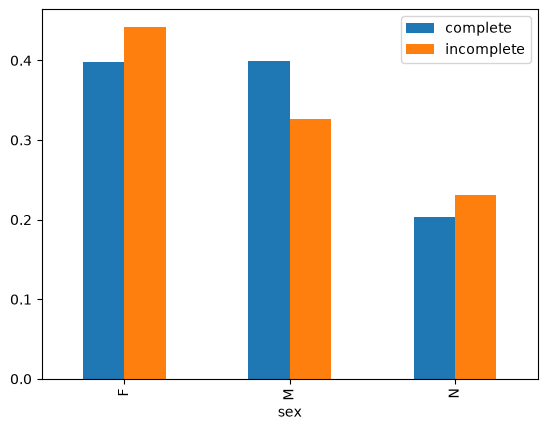

In [26]:

sg = (student_raw.groupby('sex').count()['uuid']/len(student_raw)).rename('complete')
mg = (missing_course_taken.groupby('sex').count()['uuid']/len(missing_course_taken)).rename('incomplete')
df = pd.concat([sg, mg], axis=1)
df.plot.bar()

<Axes: xlabel='job_id'>

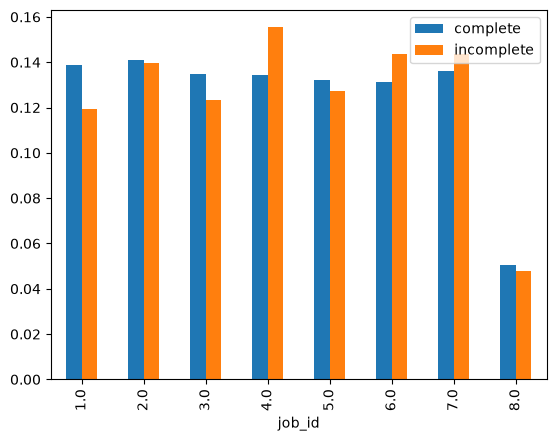

In [27]:
sg = (student_raw.groupby('job_id').count()['uuid']/len(student_raw)).rename('complete')
mg = (missing_course_taken.groupby('job_id').count()['uuid']/len(missing_course_taken)).rename('incomplete')
df = pd.concat([sg, mg], axis=1)
df.plot.bar()

<Axes: xlabel='age_group'>

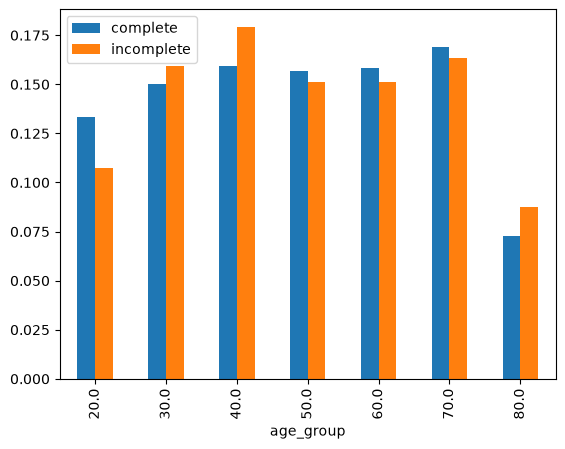

In [28]:
sg = (student_raw.groupby('age_group').count()['uuid']/len(student_raw)).rename('complete')
mg = (missing_course_taken.groupby('age_group').count()['uuid']/len(missing_course_taken)).rename('incomplete')
df = pd.concat([sg, mg], axis=1)
df.plot.bar()

In [30]:
missing_data = pd.DataFrame()
missing_data = pd.concat([missing_data, missing_course_taken])
student_raw = student_raw.dropna(subset=['num_course_taken'])


In [31]:
student_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4749 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   uuid                    4749 non-null   int64         
 1   name                    4749 non-null   object        
 2   dob                     4749 non-null   datetime64[ns]
 3   sex                     4749 non-null   object        
 4   job_id                  4744 non-null   float64       
 5   num_course_taken        4749 non-null   float64       
 6   current_career_path_id  4298 non-null   float64       
 7   time_spent_hrs          4298 non-null   float64       
 8   age                     4749 non-null   float64       
 9   age_group               4749 non-null   float64       
 10  email                   4749 non-null   object        
 11  street                  4749 non-null   object        
 12  city                    4749 non-null   object       

In [32]:
missing_job_id = student_raw[student_raw[['job_id']].isnull().any(axis=1)]
missing_job_id.head()

,uuid,name,dob,sex,job_id,num_course_taken,current_career_path_id,time_spent_hrs,age,age_group,email,street,city,state,zip_code
162,163,Glen Riley,2002-08-22,M,NaN,8.0,3.0,5.70,23.0,20.0,glen_riley4484@hmail.com,P.O. Box 37267,Cornlea village,Tennessee,19192
757,758,Mercedez Vorberg,2002-03-25,F,NaN,15.0,4.0,4.14,24.0,20.0,mercedez6297@woohoo.com,284 Cedar Seventh,Virden village,Washington,60489
854,855,Kurt Ho,2002-05-29,M,NaN,0.0,8.0,23.72,24.0,20.0,ho6107@inlook.com,P.O. Box 27254,Olin,New Hampshire,60067
1029,1030,Penny Gaines,2002-03-01,N,NaN,15.0,4.0,16.25,24.0,20.0,gaines2897@hmail.com,138 Misty Vale,Stockton borough,West Virginia,53630
1542,1543,Frederick Reilly,2002-11-13,M,NaN,7.0,9.0,21.32,23.0,20.0,frederick_reilly6971@woohoo.com,P.O. Box 40769,Quakervillage,Maryland,96218


In [33]:
missing_data = pd.concat([missing_data, missing_job_id])
student_raw = student_raw.dropna(subset=['job_id'])

In [34]:
student_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4744 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   uuid                    4744 non-null   int64         
 1   name                    4744 non-null   object        
 2   dob                     4744 non-null   datetime64[ns]
 3   sex                     4744 non-null   object        
 4   job_id                  4744 non-null   float64       
 5   num_course_taken        4744 non-null   float64       
 6   current_career_path_id  4293 non-null   float64       
 7   time_spent_hrs          4293 non-null   float64       
 8   age                     4744 non-null   float64       
 9   age_group               4744 non-null   float64       
 10  email                   4744 non-null   object        
 11  street                  4744 non-null   object        
 12  city                    4744 non-null   object       

In [36]:
missing_path_id = student_raw[student_raw[['current_career_path_id']].isnull().any(axis=1)]


In [39]:
missing_path_id.head()

,uuid,name,dob,sex,job_id,num_course_taken,current_career_path_id,time_spent_hrs,age,age_group,email,street,city,state,zip_code
15,16,Norene Dalton,1976-04-30,F,6.0,0.0,NaN,NaN,50.0,50.0,norene_dalton9509@hmail.com,130 Wishing Essex,Branch,Ohio,13616
19,20,Sofia van Steenbergen,1990-02-21,N,7.0,13.0,NaN,NaN,36.0,30.0,vansteenbergen8482@inlook.com,634 Clear Barn Dell,Beaman,Georgia,33288
30,31,Christoper Warner,1989-12-28,M,2.0,5.0,NaN,NaN,36.0,30.0,warner5906@coldmail.com,556 Stony Highlands,Drain,Illinois,01973
49,50,Antony Horne,1996-05-29,M,3.0,2.0,NaN,NaN,30.0,30.0,antony577@coldmail.com,P.O. Box 78685,Lenox,Texas,15516
54,55,Omar Bunk,1955-11-08,M,3.0,14.0,NaN,NaN,70.0,70.0,omar1245@coldmail.com,445 Dale Hollow,Vermont village,South Carolina,28329


In [40]:
missing_path_id.info()

<class 'pandas.core.frame.DataFrame'>
Index: 451 entries, 15 to 4974
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   uuid                    451 non-null    int64         
 1   name                    451 non-null    object        
 2   dob                     451 non-null    datetime64[ns]
 3   sex                     451 non-null    object        
 4   job_id                  451 non-null    float64       
 5   num_course_taken        451 non-null    float64       
 6   current_career_path_id  0 non-null      float64       
 7   time_spent_hrs          0 non-null      float64       
 8   age                     451 non-null    float64       
 9   age_group               451 non-null    float64       
 10  email                   451 non-null    object        
 11  street                  451 non-null    object        
 12  city                    451 non-null    object       

In [41]:

student_raw['current_career_path_id'].unique()

array([ 1.,  8.,  9.,  3.,  6., 10.,  5., nan,  4.,  7.,  2.])

In [42]:
student_raw['current_career_path_id'] = np.where(student_raw['current_career_path_id'].isnull(), 0, student_raw['current_career_path_id'])
student_raw['time_spent_hrs'] = np.where(student_raw['time_spent_hrs'].isnull(), 0, student_raw['time_spent_hrs'])


In [43]:
student_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4744 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   uuid                    4744 non-null   int64         
 1   name                    4744 non-null   object        
 2   dob                     4744 non-null   datetime64[ns]
 3   sex                     4744 non-null   object        
 4   job_id                  4744 non-null   float64       
 5   num_course_taken        4744 non-null   float64       
 6   current_career_path_id  4744 non-null   float64       
 7   time_spent_hrs          4744 non-null   float64       
 8   age                     4744 non-null   float64       
 9   age_group               4744 non-null   float64       
 10  email                   4744 non-null   object        
 11  street                  4744 non-null   object        
 12  city                    4744 non-null   object       

## WORKING WITH courses_raw TABLE

In [47]:
display(courses_raw)

,career_path_id,career_path_name,hours_to_complete
0,1,data scientist,20
1,2,data engineer,20
2,3,data analyst,12
3,4,software engineering,25
4,5,backend engineer,18
5,6,frontend engineer,20
6,7,iOS developer,27
7,8,android developer,27
8,9,machine learning engineer,35
9,10,ux/ui designer,15


In [48]:
courses_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   career_path_id     10 non-null     int64 
 1   career_path_name   10 non-null     object
 2   hours_to_complete  10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [49]:
not_applicable = {
    'career_path_id':0,
    'career_path_name':'not applicable',
    'hours_to_complete': 0
}
courses_raw.loc[len(courses_raw)] = not_applicable
display(courses_raw)

,career_path_id,career_path_name,hours_to_complete
0,1,data scientist,20
1,2,data engineer,20
2,3,data analyst,12
3,4,software engineering,25
4,5,backend engineer,18
5,6,frontend engineer,20
6,7,iOS developer,27
7,8,android developer,27
8,9,machine learning engineer,35
9,10,ux/ui designer,15


## WORKING WITH jobs_raw TABLE

In [51]:
display(jobs_raw)

,job_id,job_category,avg_salary
0,1,analytics,86000
1,2,engineer,101000
2,3,software developer,110000
3,4,creative,66000
4,5,financial services,135000
5,6,education,61000
6,7,HR,80000
7,8,student,10000
8,9,healthcare,120000
9,0,other,80000


In [52]:
jobs_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   job_id        13 non-null     int64 
 1   job_category  13 non-null     object
 2   avg_salary    13 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 444.0+ bytes


In [55]:
jobs_raw.drop_duplicates(inplace=True)
display(jobs_raw)

,job_id,job_category,avg_salary
0,1,analytics,86000
1,2,engineer,101000
2,3,software developer,110000
3,4,creative,66000
4,5,financial services,135000
5,6,education,61000
6,7,HR,80000
7,8,student,10000
8,9,healthcare,120000
9,0,other,80000


## JOINING TABLES

In [57]:
student_raw['job_id'] = student_raw['job_id'].astype(int)
student_raw['current_career_path_id'] = student_raw['current_career_path_id'].astype(int)

In [60]:
final_df = student_raw.merge(courses_raw, left_on = 'current_career_path_id', right_on = 'career_path_id', how = 'left')
final_df = final_df.merge(jobs_raw, on= 'job_id', how='left')
final_df.head()

,uuid,name,dob,sex,job_id,num_course_taken,current_career_path_id,time_spent_hrs,age,age_group,email,street,city,state,zip_code,career_path_id,career_path_name,hours_to_complete,job_category,avg_salary
0,1,Annabelle Avery,1943-07-03,F,7,6.0,1,4.99,83.0,80.0,annabelle_avery9376@woohoo.com,303 N Timber Key,Irondale,Wisconsin,84736,1,data scientist,20,HR,80000
1,2,Micah Rubio,1991-02-07,M,7,5.0,8,4.40,35.0,30.0,rubio6772@hmail.com,767 Crescent Fair,Shoals,Indiana,37439,8,android developer,27,HR,80000
2,3,Hosea Dale,1989-12-07,M,7,8.0,8,6.74,36.0,30.0,hosea_dale8084@coldmail.com,P.O. Box 41269,St. Bonaventure,Virginia,83637,8,android developer,27,HR,80000
3,4,Mariann Kirk,1988-07-31,F,6,7.0,9,12.31,38.0,30.0,kirk4005@hmail.com,517 SE Wintergreen Isle,Lane,Arkansas,82242,9,machine learning engineer,35,education,61000
4,5,Lucio Alexander,1963-08-31,M,7,14.0,3,5.64,62.0,60.0,alexander9810@hmail.com,18 Cinder Cliff,Doyles borough,Rhode Island,73737,3,data analyst,12,HR,80000


In [62]:
final_df.info()
con.close()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4744 entries, 0 to 4743
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   uuid                    4744 non-null   int64         
 1   name                    4744 non-null   object        
 2   dob                     4744 non-null   datetime64[ns]
 3   sex                     4744 non-null   object        
 4   job_id                  4744 non-null   int64         
 5   num_course_taken        4744 non-null   float64       
 6   current_career_path_id  4744 non-null   int64         
 7   time_spent_hrs          4744 non-null   float64       
 8   age                     4744 non-null   float64       
 9   age_group               4744 non-null   float64       
 10  email                   4744 non-null   object        
 11  street                  4744 non-null   object        
 12  city                    4744 non-null   object  

In [63]:
sqlite_connection = sqlite3.connect('cademy_cleansed.db')
final_df.to_sql('cademycode_aggregated',sqlite_connection, if_exists='replace')

4744

In [64]:
db_df = pd.read_sql_query("SELECT * FROM cademycode_aggregated", sqlite_connection)

In [65]:
db_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4744 entries, 0 to 4743
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   index                   4744 non-null   int64  
 1   uuid                    4744 non-null   int64  
 2   name                    4744 non-null   object 
 3   dob                     4744 non-null   object 
 4   sex                     4744 non-null   object 
 5   job_id                  4744 non-null   int64  
 6   num_course_taken        4744 non-null   float64
 7   current_career_path_id  4744 non-null   int64  
 8   time_spent_hrs          4744 non-null   float64
 9   age                     4744 non-null   float64
 10  age_group               4744 non-null   float64
 11  email                   4744 non-null   object 
 12  street                  4744 non-null   object 
 13  city                    4744 non-null   object 
 14  state                   4744 non-null   

In [66]:
missing_data.to_sql('incomplete_data', sqlite_connection, if_exists='replace', index=False)


256

In [67]:
missing_df = pd.read_sql_query("SELECT * FROM incomplete_data", sqlite_connection)
sqlite_connection.close()


In [68]:
db_df.to_csv('cademycode_cleansed.csv')